# Simple Simulator for User Association

## 1. BaseStation Class

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

from typing import List, Tuple 
from collections import deque 

# Parameters 
C = 3e8 
AREA_SIZE = 100 
NUM_BS = 4 
NUM_UE = 20
COVERAGE_RADIUS = 35    # Small Cell coverage radius 


class BaseStation: 
    """
    Base class representing a general base station. 
    Includes basic attributes like position, transmit power, frequency, gain and path loss model. 
    """
    def __init__(self, 
                 bs_id, 
                 position, 
                 tx_power_dbm, 
                 frequency,
                 antenna_gain_tx,
                 antenna_gain_rx, 
                 bandwidth,
                 shadowing_std_dev, 
                 path_loss_exp, 
                 reference_distance, 
                 noise_figure_db, 
                 beam_limit=np.inf,): 
        self.bs_id = bs_id      # Unique identifier for the base station        
        self.position = np.array(position)  # Position in Cartesian coordinates (x, y)
        self.tx_power_dbm = tx_power_dbm    # Transmit power in dBm
        self.frequency = frequency  
        self.wavelength = C / frequency 
        self.antenna_gain_tx = antenna_gain_tx  # Antenna gain for transmission in dBi
        self.antenna_gain_rx = antenna_gain_rx  # Antenna gain for reception in dBi
        self.bandwidth = bandwidth
        self.shadowing_std_dev = shadowing_std_dev  # Standard deviation for shadowing in dB
        self.path_loss_exp = path_loss_exp  
        self.reference_distance = reference_distance
        self.noise_figure_db = noise_figure_db
        self.beam_limit = beam_limit
        self.connected_users = []   # List of connected users

    def distance_to(self, user_pos): 
        """
        Calculate the Euclidean distance to a user position.
        :param user_pos(np.ndarray): Position of the user in Cartesian coordinates (x, y)
        :return: Distance in meters
        """
        return np.linalg.norm(self.position - user_pos)

    def path_loss(self, distance): 
        """ 
        Calculate the path loss based on the close-in free space refrerence distance model.
        :param distance(float): Distance to the user in meters
        :return: Path loss in dB
        """
        fspl_db = 20 * np.log10(4 * np.pi * self.reference_distance / self.wavelength) 
        pl_db = fspl_db + 10 * self.path_loss_exp * np.log10(distance / self.reference_distance) 
        shadowing = np.random.normal(0, self.shadowing_std_dev) # Shadowing effect
        return pl_db + shadowing
    
    def receive_power(self, distance): 
        """ 
        Calculate the received power in dBm based on ditance and path loss.
        :param distance(float): Distance to the user in meters 
        :return: Received power in dBm
        """
        path_loss_db = self.path_loss(distance) 
        return self.tx_power_dbm + self.antenna_gain_tx + self.antenna_gain_rx - path_loss_db
    
    def can_serve(self, user_pos): 
        """Default to always serve unless overridden. (e.g., for small cells and limited coverage)"""
        return True 
    
    def reset(self): 
        """Reset the connected users list."""
        self.connected_users = []
    


In [4]:
class MacroBaseStation(BaseStation): 
    """
    Represents a macro base station with full coverage of the area. 
    """
    def __init__(self, bs_id, position): 
        super().__init__(bs_id=bs_id, 
                         position=position, 
                         tx_power_dbm=46, 
                         frequency=2e9, 
                         antenna_gain_tx=17, 
                         antenna_gain_rx=0,
                         bandwidth=10e6, 
                         shadowing_std_dev=np.sqrt(9), 
                         path_loss_exp=3.76,
                         reference_distance=20.7, 
                         noise_figure_db=5,
                         beam_limit=np.inf)
        
    def can_serve(self, user_pos): 
        return True 
    

class SmallCellBaseStation(BaseStation): 
    """ 
    Represents a small cell base station with liimited coverage radius (default=35m) 
    """
    def __init__(self, bs_id, position, beam_limit, coverage_radius=COVERAGE_RADIUS): 
        super().__init__(bs_id=bs_id, 
                         position=position, 
                         tx_power_dbm=20, 
                         frequency=28e9,            # 28 GHz frequency for small cells
                         antenna_gain_tx=0,         # Tx Antenna gain = 0dB (1.0)
                         antenna_gain_rx=0,         # Rx Antenna gain = 0dB (1.0) 
                         bandwidth=500e6,           # Bandwidth = 500MHz
                         shadowing_std_dev=np.sqrt(12), 
                         path_loss_exp=2.5,         # Path-loss coefficient 
                         reference_distance=5,      # Reference distance 
                         noise_figure_db=0,         
                         beam_limit=beam_limit, )
        self.coverage_radius = coverage_radius

    def can_serve(self, user_pos): 
        """Smalle cell can only serve users within its coverage radius. """
        return self.distance_to(user_pos) <= self.coverage_radius 
    
    def path_loss(self, distance): 
        """ 
        Calculate the path loss for small cells using a different model. According to the paper 
        :param distance(float): Distance to the user in meters 
        :return : path loss in dB 
        """
        return 128.1 + 37.6 * np.log10(distance / 1000) 



In [5]:
#### Triangle Layout (Setting up Base stations) #### 
spacing = 1.2 * COVERAGE_RADIUS  # Spacing between base stations    
center_x, center_y = AREA_SIZE / 2, AREA_SIZE / 2
beam_limits = [2, 3, 3]

small_bs_positions = [
    (center_x - spacing / 2, center_y - spacing / (2 * np.sqrt(3))),  # Bottom left
    (center_x + spacing / 2, center_y - spacing / (2 * np.sqrt(3))),  # Bottom right
    (center_x, center_y + spacing / np.sqrt(3)),  # Top
]

# Instantiate BSs 
mbs = MacroBaseStation(bs_id=0, position=np.random.uniform(0, AREA_SIZE, size=2))  # Random position for macro BS
sbs_list = [SmallCellBaseStation(bs_id=i+1, 
                                 position=small_bs_positions[i],
                                 beam_limit=beam_limits[i]) for i in range(NUM_BS - 1)]
all_bs = [mbs] + sbs_list 


In [6]:
#### User equipment (UE) setup ####
np.random.seed(111) # For reproducibility
ue_positions = np.random.rand(NUM_UE, 2) * AREA_SIZE 


In [7]:
#### User Association Logic #### 

# Compute SNR matrix (size: UE x BS) 
snr_matrix = np.full((NUM_UE, NUM_BS), -np.inf) # Initialize with -inf for no connection

for ue_idx, ue_pos in enumerate(ue_positions): 
    for bs in all_bs: 
        if bs.can_serve(ue_pos): 
            d = bs.distance_to(ue_pos) 
            pr = bs.receive_power(d) 
            noise_power_dbm = -174 + 10 * np.log10(bs.bandwidth) + bs.noise_figure_db # Assume 10MHz BW 
            snr = pr - noise_power_dbm 
            snr_matrix[ue_idx, bs.bs_id] = snr 

# Associate each UE with the BS offering the max SNR (with only small cells)
ua_indices = np.argmax(snr_matrix[:, 1:], axis=1) + 1 



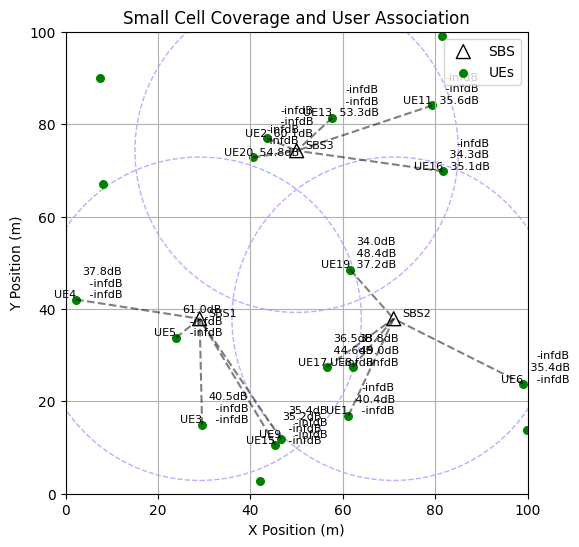

In [8]:
fig, ax = plt.subplots(figsize=(6, 6)) 

# ax.scatter(mbs.position[0], mbs.position[1], c='red', label="MBS", s=100, marker='^')  # Macro BS

for e, bs in enumerate(sbs_list): 
    ax.scatter(bs.position[0], bs.position[1], label="SBS" if e==0 else None, s=100, marker='^', facecolors='none', edgecolors='black')  # Small Cells
    ax.text(bs.position[0] + 5, bs.position[1], f'SBS{bs.bs_id}', fontsize=8, ha='center', va='bottom', color='black')
    circle = plt.Circle(bs.position, bs.coverage_radius, color='blue', fill=False, linestyle='--', alpha=0.3) 
    ax.add_patch(circle) # Coverage area of small cells

ax.scatter(ue_positions[:, 0], ue_positions[:, 1], c='green', label='UEs', s=30, marker='o')  # User Equipment

for bs in sbs_list: 
    for ue_idx, bs_idx in enumerate(ua_indices): 
        if bs.bs_id == bs_idx and bs.can_serve(ue_positions[ue_idx]): 
            ax.plot([ue_positions[ue_idx, 0], bs.position[0]],
                     [ue_positions[ue_idx, 1], bs.position[1]], 
                     color='black', linestyle='--', alpha=0.5)
            ax.text(ue_positions[ue_idx, 0], ue_positions[ue_idx, 1], 
                    f'UE{ue_idx+1}', fontsize=8, ha='right', va='bottom', color='black')
            ax.text(ue_positions[ue_idx, 0] + 10, ue_positions[ue_idx, 1],
                    f'{snr_matrix[ue_idx, 1]:.1f}dB\n {snr_matrix[ue_idx, 2]:.1f}dB\n {snr_matrix[ue_idx, 3]:.1f}dB', fontsize=8, ha='right', va='bottom', color='black')
            
ax.set_xlim(0, AREA_SIZE)
ax.set_ylim(0, AREA_SIZE)
ax.set_title("Small Cell Coverage and User Association")
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.grid()

In [9]:

class UserEquipment: 
    """ 
    A class to represent a User Equipment (UE)
    includes all necessary attributes and methods for UE operations.
    """
    def __init__(self, ue_id, position): 
        """ 
        Initialize the UE. 
        
        Paramaters: 
        - ue_id (int): Unique identifier for the UE 
        - position (tuple): Position of the UE in Cartesian coordinates (x, y)
        """
        self.ue_id = ue_id 
        self.position = np.array(position) 
        self.snr_list = {}  # Dictionary: key=BS id, value = SNR in dB 

    def add_snr(self, bs_id, snr): 
        """ 
        Add or update the SNR value from a specific base station
        
        Parameters: 
        - bs_id (int): ID of the base station
        - snr (float): Signal-to-Noise Ratio in dB
        """
        self.snr_list[bs_id] = snr 

    def best_bs(self): 
        """ 
        Return the base station ID with the maximum SNR, besides the macro base station
        """
        if not self.snr_list: 
            return None 
        # Exclude MBS (bs_id=0) from the best BS selection 
        candidates = {k: v for k, v in self.snr_list.items() if k != 0}

        return max(candidates, key=candidates.get) if candidates else None
    
    def get_snr(self, bs_id): 
        """ 
        Retrieve SNR for a given BS. 
        
        Parameters: 
        - bs_id (int): ID of the base station 
        
        Returns: 
        - float: SNR value in dB or None if not availbale 
        """
        return self.snr_list.get(bs_id, -np.inf) 

    def __repr__(self):
        return f"UE#{self.ue_id} | [x, y] = {self.position} | Best BS: {self.best_bs()}"
    
# Example: Create UE lista nd compute SNRs 
ue_list = [UserEquipment(ue_id=i, position=pos) for i, pos in enumerate(ue_positions)]

for ue in ue_list: 
    for bs in all_bs: 
        if bs.can_serve(ue.position): 
            d = bs.distance_to(ue.position) 
            pr = bs.receive_power(d) 
            noise_power_dbm = -174 + 10 * np.log10(bs.bandwidth) + bs.noise_figure_db
            snr = pr - noise_power_dbm
            ue.add_snr(bs.bs_id, snr) 


for ue in ue_list:
    print(ue) 

UE#0 | [x, y] = [61.21701756 16.90697543] | Best BS: 2
UE#1 | [x, y] = [43.60590194 76.92624725] | Best BS: 3
UE#2 | [x, y] = [29.53253044 14.91629571] | Best BS: 1
UE#3 | [x, y] = [ 2.24783245 42.02244923] | Best BS: 1
UE#4 | [x, y] = [23.86821412 33.76561919] | Best BS: 1
UE#5 | [x, y] = [99.07124646 23.77264539] | Best BS: 2
UE#6 | [x, y] = [ 8.11926595 66.96002382] | Best BS: None
UE#7 | [x, y] = [62.12429194 27.42535302] | Best BS: 2
UE#8 | [x, y] = [46.62214099 11.83677511] | Best BS: 1
UE#9 | [x, y] = [ 7.39575641 90.07741792] | Best BS: None
UE#10 | [x, y] = [79.39625605 84.05696487] | Best BS: 3
UE#11 | [x, y] = [81.52074575 99.09548513] | Best BS: None
UE#12 | [x, y] = [57.72738296 81.3766917 ] | Best BS: 3
UE#13 | [x, y] = [42.13178774  2.74479598] | Best BS: None
UE#14 | [x, y] = [45.41366432 10.53260853] | Best BS: 1
UE#15 | [x, y] = [81.72200616 69.77277346] | Best BS: 3
UE#16 | [x, y] = [56.52854013 27.42272954] | Best BS: 2
UE#17 | [x, y] = [99.84737437 13.80420531] | B

In [10]:
def generate_triangle_coverage(area_size: float=100, 
                               coverage_radius: float=35, 
                               spacing: float=1.2) -> list: 
    """ 
    Generate a triangle layout for small cell coverage visualization. 
    
    Parameters: 
    - area_size (float): Size of the area (default=100) 
    - coverage_radius (float): Coverage radius for small cells (default=35) 
    - spacing (float): Spacing between small cells (default=1.2)

    Returns: 
    - list: List of positions for small cells in the triangle layout 
    """
    spacing = 1.2 * coverage_radius  # Spacing between base stations    
    center_x, center_y = area_size / 2, area_size / 2
    # Calculate positions of small cells in a triangle layout
    small_bs_positions = [
        (center_x - spacing / 2, center_y - spacing / (2 * np.sqrt(3))),  # Bottom left
        (center_x + spacing / 2, center_y - spacing / (2 * np.sqrt(3))), # Bottom right
        (center_x, center_y + spacing / np.sqrt(3)),  # Top
    ]
    return small_bs_positions


def engage_layout(bs_list: List[BaseStation], 
                  ue_list: List[UserEquipment]) -> dict:
    """ 
    Engage the BSs and UEs in the area
    Parameters: 
    - bs_list (List[BaseStation]): List of base stations to deploy
    - ue_list (List[UserEquipment]): List of user equipment to deploy

    Returns: 
    user association (dict): Dictionary mapping each UE to its best BS based on max-SNR
    """
    for ue in ue_list: 
        for bs in bs_list: 
            if bs.can_serve(ue.position): 
                d = bs.distance_to(ue.position) 
                pr = bs.receive_power(d) 
                noise_power_dbm = -174 + 10 * np.log10(bs.bandwidth) + bs.noise_figure_db 
                snr = pr - noise_power_dbm 
                ue.add_snr(bs.bs_id, snr) 
    
    # Create user association based on max SNR 
    user_associations = {} 
    for bs in bs_list[1:]: # iterate through small cells only 
        candidates = [(ue, ue.snr_list[bs.bs_id]) for ue in ue_list if bs.can_serve(ue.position) and bs.bs_id in ue.snr_list]
        candidates.sort(key=lambda x: x[1], reverse=True) 
        for ue, _ in candidates[:bs.beam_limit]: 
            print(f"UE#{ue.ue_id} associated with SBS#{bs.bs_id} with SNR: {ue.get_snr(bs.bs_id):.2f} dB")
            bs.connected_users.append(ue.ue_id) 
            user_associations[ue.ue_id] = bs.bs_id
    
    for ue in ue_list: 
        if ue.ue_id not in user_associations: 
            user_associations[ue.ue_id] = None

    return user_associations

                


In [14]:
###### Generate layout ######
seed = 111
np.random.seed(seed)  # For reproducibility

# make positions for the layout 
sbs_positions = generate_triangle_coverage(area_size=AREA_SIZE,
                                           coverage_radius=COVERAGE_RADIUS, 
                                           spacing=1.2)
ue_positions = np.random.rand(NUM_UE, 2) * AREA_SIZE  # Random UE positions

# Define beam limits for each small cell (e.g., 2, 3, 3)
beam_limits = [2, 3, 3]

# instantiate MBS 
mbs = MacroBaseStation(bs_id=0, 
                       position=np.random.uniform(0, AREA_SIZE, size=2))  
# instantiate SBSs 
sbs_list = [SmallCellBaseStation(bs_id=i+1, 
                          position=sbs_positions[i], 
                          beam_limit=beam_limits[i]) for i in range(NUM_BS - 1)]

all_bs = [mbs] + sbs_list

# intsantiate UEs 
ue_list = [UserEquipment(ue_id=i, position=pos) for i, pos in enumerate(ue_positions)]

# Engage the layout
user_associations = engage_layout(bs_list=all_bs, ue_list=ue_list)
print(user_associations)
# user_associations = {ue.ue_id: ue.best_bs() for ue in ue_list} 
# print("User Associations (UE ID: Best BS ID):")
# for ue_id, bs_id in user_associations.items():
#     print(f"UE{ue_id + 1}: Best BS = SBS{bs_id}" if bs_id is not None else f"UE{ue_id + 1}: Best BS =")

def compute_power(ue: UserEquipment,
                  bs: BaseStation, 
                  fading: float=None,
                  desired: bool=True, ) -> float:
    """
    Calculate the power parameters for a given UE and base station.
    Parameters:
    - ue (UserEquipment): The user equipment for which to calculate power
    - bs (BaseStation): The base station serving the UE
    
    Returns:
    - float: The calculated power in Watts
    """

    d = bs.distance_to(ue.position) # Distance to the base station
    lobe_gain = 1.0 if desired else 0.1 
    alpha = fading if fading is not None else np.random.gamma(2, 1) # Rayleigh fading parameter (m=1 nakagami fading)
    Gch = 10 ** (-bs.path_loss(d) / 10)  # Channel gain
    Gtx = 10 ** (bs.antenna_gain_tx / 10) * lobe_gain  # Transmit antenna gain
    Grx = 10 ** (bs.antenna_gain_rx / 10) * lobe_gain  # Receive antenna gain
    Ptx = (10 ** (bs.tx_power_dbm / 10) * 1e-3)  # Convert dBm to Watts
    signal_power = alpha * Ptx * Gch * Gtx * Grx 
    print(f"distance: {d:.2f} m, Path Loss: {bs.path_loss(d):.2f} dB, alpha: {alpha:.2f}, "
          f"Gch: {Gch:.2e}, Gtx: {Gtx:.2f}, Grx: {Grx:.2f}, Ptx: {Ptx:.2e} W")
    return signal_power 


def compute_sinr(ue: UserEquipment, 
                 serving_bs: BaseStation, 
                 all_bs: List[BaseStation], 
                 ue_list: List[UserEquipment], 
                 debug=False) -> float: 
    """ 
    Compute the Signal-to-Interference-plus-Noise Ratio (SINR) for a given UE. 
    
    Parameters: 
    - ue (UserEquipment): The user equipment for which to compute the SINR 
    - serving_bs (BaseStation): The base station object, which is serving the UE 
    - all_bs (List[BaseStation]): List of all base stations in the area
    - ue_list (List[UserEquipment]): List of all user equipment in the area
    
    Returns: 
    - sinr_db (float): The computed SINR in dB 
    """

    ### Compute SINR for UE1 
    serving_bs = all_bs[ue.best_bs()]

    ### 1. Desired signal power calculation 
    d = serving_bs.distance_to(ue.position) 
    alpha = np.random.gamma(2, 1) # Rayleigh fading parameter (m=1 nakagami fading)
    Gch = 10 ** (-serving_bs.path_loss(d) / 10) 
    Gtx = 10 ** (serving_bs.antenna_gain_tx / 10) 
    Grx = 10 ** (serving_bs.antenna_gain_rx / 10) 
    Ptx = (10 ** (serving_bs.tx_power_dbm/ 10) * 1e-3)  # Convert dBm to Watts
    desired_signal_power = alpha * Ptx * Gch * Gtx * Grx
    desired_signal_power_f = compute_power(ue, serving_bs, fading=alpha, desired=True)

    # Print UEs with their best BS 
    # ue_list[:]


    ### 2. Intra-cell interference calculation 
    intra_interference = 0.0 
    intra_interference_f = 0.0 

    if isinstance(serving_bs, SmallCellBaseStation): 
        for other_ue in ue_list: 
            if other_ue.ue_id != ue.ue_id and user_associations[other_ue.ue_id] == serving_bs.bs_id: 
                d_intra = serving_bs.distance_to(other_ue.position) 
                alpha_i = np.random.gamma(2, 1) 
                Gch_i = 10 ** (-serving_bs.path_loss(d_intra) / 10)
                Gtx_i = 10 ** (serving_bs.antenna_gain_tx / 10) * 0.1   # Assume Sidelobe gain as 0.1 of the main lobe peak
                Grx_i = 10 ** (serving_bs.antenna_gain_rx / 10) * 0.1   
                Ptx_i = 10 ** (serving_bs.tx_power_dbm / 10) * 1e-3 
                intra_interference += alpha_i * Ptx_i * Gch_i * Gtx_i * Grx_i
                intra_interference_f += compute_power(other_ue, serving_bs, fading=alpha_i, desired=False)




    ### 3. Inter-cell interference calculation 
    inter_interference = 0.0
    inter_interference_f = 0.0

    for bs in all_bs: 
        if bs.bs_id != serving_bs.bs_id: # Exlude the serving BS 
            for other_ue in ue_list: 
                if user_associations[other_ue.ue_id] == bs.bs_id: 
                    d_inter = bs.distance_to(ue.position) 
                    alpha_i = np.random.gamma(2, 1) 
                    Gch_i = 10 ** (-bs.path_loss(d_inter) / 10)
                    Gtx_i = 10 ** (bs.antenna_gain_tx / 10) * 0.1   # Assume Sidelobe gain as 0.1 of the main lobe peak
                    Grx_i = 10 ** (bs.antenna_gain_rx / 10) * 0.1
                    Ptx_i = 10 ** (bs.tx_power_dbm / 10) * 1e-3
                    inter_interference += alpha_i * Ptx_i * Gch_i * Gtx_i * Grx_i
                    inter_interference_f += compute_power(ue, bs, fading=alpha_i, desired=False)


    ### 4. Noise power calculation 
    noise_psd_dbm_Hz = -174 
    noise_psd = 10 ** (noise_psd_dbm_Hz / 10) * 1e-3  # Convert dBm/Hz to W/Hz
    bandwidth = serving_bs.bandwidth  # Bandwidth in Hz
    # print(f"Bandwidth: {bandwidth / 1e6} MHz")
    noise_power = noise_psd * bandwidth 

    ### 5. SINR Calculation 
    sinr =  desired_signal_power / (intra_interference + inter_interference + noise_power)
    sinr_f = desired_signal_power_f / (intra_interference_f + inter_interference_f + noise_power)  # Using the compute_power function
    sinr_db = 10 * np.log10(sinr)  # Convert to dB

    if debug: 
        print(f"distance: {d:.2f} m, Path Loss: {serving_bs.path_loss(d):.2f} dB, alpha: {alpha:.2f}, "
                f"Gch: {Gch:.2e}, Gtx: {Gtx:.2f}, Grx: {Grx:.2f}, Ptx: {Ptx:.2e} W")
        print(f"Desired Signal Power: {desired_signal_power:.2e} W")
        print(f"Desired Signal Power: {compute_power(ue, serving_bs, fading=alpha):.2e} W")  # Using the compute_power function
        print(f"Intra-cell Interference: {intra_interference:.2e} W")
        print(f"Intra-cell Interference (using compute_power): {intra_interference_f:.2e} W")  # Using the compute_power function
        print(f"Inter-cell Interference: {inter_interference:.2e} W")
        print(f"Inter-cell Interference (using compute_power): {inter_interference_f:.2e} W")  # Using the compute_power function
        print(f"Noise Power: {noise_power:.2e} W")
        print(f"SINR: {sinr:.2e} W, {sinr_db:.2f} dB")
        print(f"SINR (using compute_power): {sinr_f:.2e} W, {10 * np.log10(sinr_f):.2f} dB")
    
    return sinr_db, sinr 


ue = ue_list[6]  # Example UE
serving_bs = all_bs[ue.best_bs()]  # Get the serving base station for the UE
sinr_db, sinr = compute_sinr(ue=ue, 
                             serving_bs=serving_bs, 
                             all_bs=all_bs, 
                             ue_list=ue_list, 
                             debug=True)
print(f"UE#{ue.ue_id} associated with SBS#{serving_bs.bs_id} with SINR: {sinr_db:.2f} dB")


UE#4 associated with SBS#1 with SNR: 60.96 dB
UE#2 associated with SBS#1 with SNR: 40.53 dB
UE#7 associated with SBS#2 with SNR: 48.96 dB
UE#18 associated with SBS#2 with SNR: 48.35 dB
UE#16 associated with SBS#2 with SNR: 44.65 dB
UE#1 associated with SBS#3 with SNR: 60.09 dB
UE#19 associated with SBS#3 with SNR: 54.76 dB
UE#12 associated with SBS#3 with SNR: 53.29 dB
{4: 1, 2: 1, 7: 2, 18: 2, 16: 2, 1: 3, 19: 3, 12: 3, 0: None, 3: None, 5: None, 6: None, 8: None, 9: None, 10: None, 11: None, 13: None, 14: None, 15: None, 17: None}


TypeError: list indices must be integers or slices, not NoneType

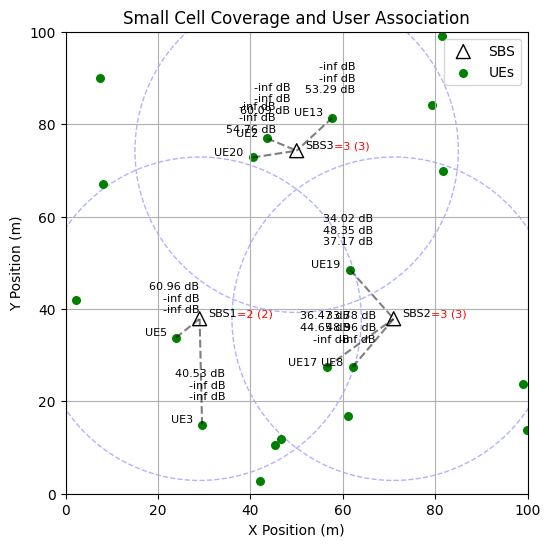

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Small-cell BSs 
for bs in sbs_list: 
    ax.scatter(bs.position[0], bs.position[1], label="SBS" if bs.bs_id == 1 else None,
               s=100, marker='^', facecolors='none', edgecolors='black')  # Small Cells
    ax.text(bs.position[0] + 5, bs.position[1], f'SBS{bs.bs_id}', fontsize=8, ha='center', va='bottom', color='black')
    ax.text(bs.position[0] + 12, bs.position[1], f'={bs.beam_limit} ({len(bs.connected_users)})', fontsize=8, ha='center', va='bottom', color='red')
    circle = plt.Circle(bs.position, bs.coverage_radius, color='blue', fill=False, linestyle='--', alpha=0.3)
    ax.add_patch(circle)  # Coverage area of small cells

# Scatter UEs 
ax.scatter(ue_positions[:, 0], ue_positions[:, 1], c='green', label='UEs', s=30, marker='o')  # User Equipment

# Draw lines between UEs and their associated BSs based on user_associations
for ue in ue_list: 
    associated_bs_id = user_associations.get(ue.ue_id)  # Get the associated BS ID for the UE
    if associated_bs_id is not None: 
        associated_bs = next(bs for bs in all_bs if bs.bs_id == associated_bs_id)  # Find the associated BS object
        ax.plot([ue.position[0], associated_bs.position[0]],
                 [ue.position[1], associated_bs.position[1]], 
                 color='black', linestyle='--', alpha=0.5)
        ax.text(ue.position[0] - 2, ue.position[1], 
                f'UE{ue.ue_id+1}', fontsize=8, ha='right', va='bottom', color='black')
        snr_values = [f'{ue.get_snr(i):.2f} dB' for i in range(1, NUM_BS)]  # SNR values for small cells
        ax.text(ue.position[0] + 5, ue.position[1] + 5,
                '\n'.join(snr_values), fontsize=8, ha='right', va='bottom', color='black')

ax.set_xlim(0, AREA_SIZE)
ax.set_ylim(0, AREA_SIZE)
ax.set_title("Small Cell Coverage and User Association")
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.grid()
plt.show()

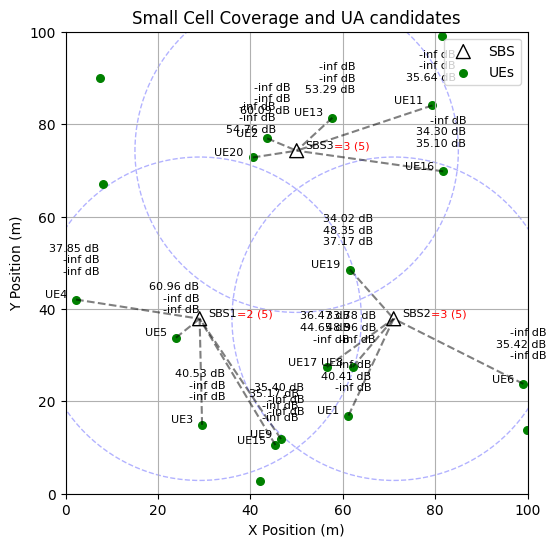

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Small-cell BSs 
for bs in sbs_list: 
    ax.scatter(bs.position[0], bs.position[1], label="SBS" if bs.bs_id == 1 else None,
               s=100, marker='^', facecolors='none', edgecolors='black')  # Small Cells
    ax.text(bs.position[0] + 5, bs.position[1], f'SBS{bs.bs_id}', fontsize=8, ha='center', va='bottom', color='black')
    circle = plt.Circle(bs.position, bs.coverage_radius, color='blue', fill=False, linestyle='--', alpha=0.3)
    ax.add_patch(circle)  # Coverage area of small cells

# Scatter UEs 
ax.scatter(ue_positions[:, 0], ue_positions[:, 1], c='green', label='UEs', s=30, marker='o')  # User Equipment

# Draw lines between UEs and their best BS 

for bs in sbs_list: 
    num_links = 0
    for ue in ue_list: 
        best_bs_id = ue.best_bs()  # Get the best BS for the UE
        if best_bs_id == bs.bs_id and bs.can_serve(ue.position): 
            num_links += 1
            ax.plot([ue.position[0], bs.position[0]],
                     [ue.position[1], bs.position[1]], 
                     color='black', linestyle='--', alpha=0.5)
            ax.text(ue.position[0] - 2, ue.position[1], 
                    f'UE{ue.ue_id+1}', fontsize=8, ha='right', va='bottom', color='black')
            snr_values = [f'{ue.get_snr(i):.2f} dB' for i in range(1, NUM_BS)]  # SNR values for small cells
            ax.text(ue.position[0] + 5, ue.position[1] + 5,
                    '\n'.join(snr_values), fontsize=8, ha='right', va='bottom', color='black')
    ax.text(bs.position[0] + 12, bs.position[1], f'={bs.beam_limit} ({num_links})', fontsize=8, ha='center', va='bottom', color='red')

ax.set_xlim(0, AREA_SIZE)
ax.set_ylim(0, AREA_SIZE)
ax.set_title("Small Cell Coverage and UA candidates")
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.grid()
plt.show()



In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

from test_env.UA.components.basestation import MacroBaseStation, SmallCellBaseStation
from test_env.UA.components.user_equipment import UserEquipment 
